#### Dataset Title: Football Players Data
#### Dataset source link: https://www.kaggle.com/datasets/maso0dahmed/football-players-data/data

#### Dataset features description:

| Column | Description | Column | Description | Column | Description |
|---|---|---|---|---|---|
| name | Name of the player. | body_type | Player's body type. | ball_control | Rating for ball control. |
| full_name | Full name of the player. | release_clause_euro | Release clause of the player in euros. | acceleration | Rating for acceleration. |
| birth_date | Date of birth of the player. | national_team | National team of the player. | sprint_speed | Rating for sprint speed. |
| age | Age of the player. | national_rating | Rating in the national team. | agility | Rating for agility. |
| height_cm | Player's height in centimeters. | national_team_position | Position in the national team. | reactions | Rating for reactions. |
| weight_kgs | Player's weight in kilograms. | national_jersey_number | Jersey number in the national team. | balance | Rating for balance. |
| positions | Positions the player can play. | crossing | Rating for crossing ability. | shot_power | Rating for shot power. |
| nationality | Player's nationality. | finishing | Rating for finishing ability. | jumping | Rating for jumping. |
| overall_rating | Overall rating of the player in FIFA. | heading_accuracy | Rating for heading accuracy. | stamina | Rating for stamina. |
| potential | Potential rating of the player in FIFA. | short_passing | Rating for short passing ability. | strength | Rating for strength. |
| value_euro | Market value of the player in euros. | volleys | Rating for volleys. | long_shots | Rating for long shots. |
| wage_euro | Weekly wage of the player in euros. | dribbling | Rating for dribbling. | aggression | Rating for aggression. |
| preferred_foot | Player's preferred foot. | curve | Rating for curve shots. | interceptions | Rating for interceptions. |
| international_reputation(1-5) | International reputation rating from 1 to 5. | freekick_accuracy | Rating for free kick accuracy. | positioning | Rating for positioning. |
| weak_foot(1-5) | Rating of the player's weaker foot from 1 to 5. | long_passing | Rating for long passing. | vision | Rating for vision. |
| skill_moves(1-5) | Skill moves rating from 1 to 5. | penalties | Rating for penalties. | marking | Rating for marking. |
| composure | Rating for composure. | standing_tackle | Rating for standing tackle. | sliding_tackle | Rating for sliding tackle. |

### Imports
---

In [915]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [916]:
data = pd.read_csv('../data/fifa_players.csv')
data

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17


In [917]:
# dataset dimensions
data.shape

(17954, 51)

In [918]:
# Features type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

In [919]:
data.isna().sum()

name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro               1837
national_team                    17097
national_rating                  17097
national_team_position           17097
national_jersey_number           17097
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

In [920]:
# Players who do not play for the national team of the country where they were born.

# One part of the analysis will include a profile of players who may be underrated based on their sporting attributes
# and are not included in the national team.

# The feature `national_rating` has the same number of missing values as the feature `national_team`.
# This most likely means that `national_rating` is calculated only for players who are included in their national teams.
data[data['national_team'].isna()]

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87
16,M. Škriniar,Milan Škriniar,2/11/1995,24,187.96,79.8,CB,Slovakia,86,93,...,30,86,86,30,57,56,81,92,89,84
17,Fernandinho,Fernando Luiz Rosa,5/4/1985,33,152.40,67.1,CDM,Brazil,87,87,...,78,87,89,70,75,61,79,87,86,80
18,G. Higuaín,Gonzalo Gerardo Higuaín,12/10/1987,31,185.42,88.9,ST,Argentina,87,87,...,80,50,20,92,74,70,86,35,22,18
19,I. Rakitić,Ivan Rakitić,3/10/1988,30,182.88,78.0,"CM,CDM",Croatia,87,87,...,87,67,81,80,86,82,86,76,75,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17


There are also other missing values in some of the features in the dataset, but their number is not very large.

During the data preprocessing stage, we will decide how to handle them. One possible approach is to fill them with the average wage of the team the player belongs to.

At this stage, no action will be taken.

### Feature analysis and preprocessing
---

#### 1. Age analysis

In [921]:
# Descriptive statistics for player age
data['age'].describe()

count    17954.000000
mean        25.565445
std          4.705708
min         17.000000
25%         22.000000
50%         25.000000
75%         29.000000
max         46.000000
Name: age, dtype: float64

In [922]:
# No missing values
data['age'].isna().sum()

np.int64(0)

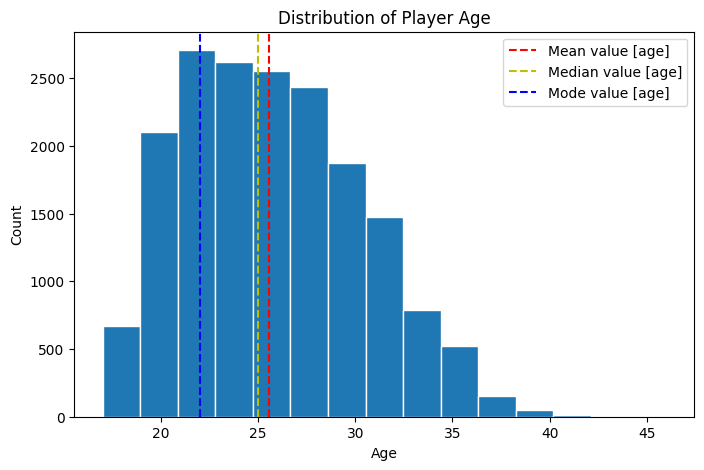

In [923]:
plt.figure(figsize=(8, 5))
mean_age = data['age'].mean()
meadian_age = data['age'].median()
mode_age = data['age'].mode().iloc[0]

plt.hist(data['age'], bins=15, edgecolor='white')
plt.axvline(mean_age, color='r', linestyle = '--', label='Mean value [age]')
plt.axvline(meadian_age, color='y', linestyle = '--', label='Median value [age]')
plt.axvline(mode_age, color='b', linestyle = '--', label='Mode value [age]')

plt.title('Distribution of Player Age')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

In [924]:
mode_age

np.int64(22)

Most football players are concentrated around the age of 22.

In [925]:
meadian_age

np.float64(25.0)

In [926]:
mean_age

np.float64(25.56544502617801)

The mean and median age are very close, which suggests that the age distribution is relatively balanced and not strongly affected by extreme values.

#### 2. height_cm / weight_kgs analysis

In [927]:
data['height_cm'].describe()

count    17954.000000
mean       174.946921
std         14.029449
min        152.400000
25%        154.940000
50%        175.260000
75%        185.420000
max        205.740000
Name: height_cm, dtype: float64

In [928]:
# No missing values
data['height_cm'].isna().sum()

np.int64(0)

In [929]:
# Here, we examine the players’ height and whether lower height could be related to younger age.
# However, we can see that even the shortest football players are between 17 and 42 years old.
# These physical characteristics are not always a leading factor,
# but it is certainly important to analyze this indicator in order to understand what is typical.
data[data['height_cm'] < 160]['age'].describe()

count    4515.000000
mean       25.375194
std         4.707351
min        17.000000
25%        22.000000
50%        25.000000
75%        29.000000
max        42.000000
Name: age, dtype: float64

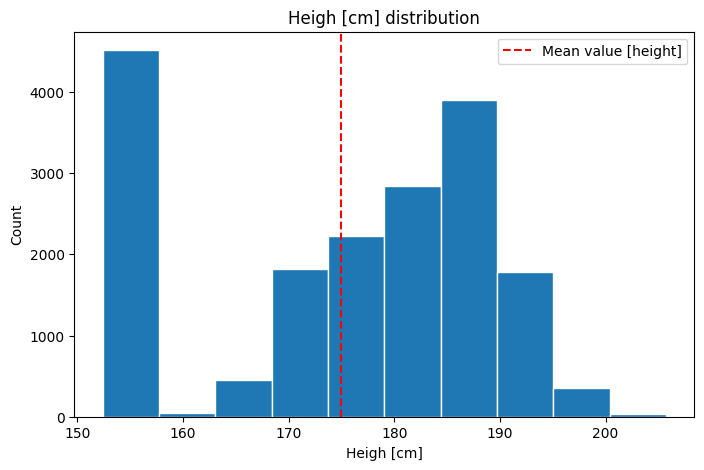

In [930]:
plt.figure(figsize=(8, 5))
mean_height = data['height_cm'].mean()


plt.hist(data['height_cm'], bins=10, edgecolor='white')
plt.axvline(mean_height, color='r', linestyle = '--', label='Mean value [height]')

plt.xlabel('Heigh [cm]')
plt.ylabel('Count')
plt.title('Heigh [cm] distribution')
plt.legend()
plt.show()

In [931]:
data['weight_kgs'].describe()

count    17954.000000
mean        75.301047
std          7.083684
min         49.900000
25%         69.900000
50%         74.800000
75%         79.800000
max        110.200000
Name: weight_kgs, dtype: float64

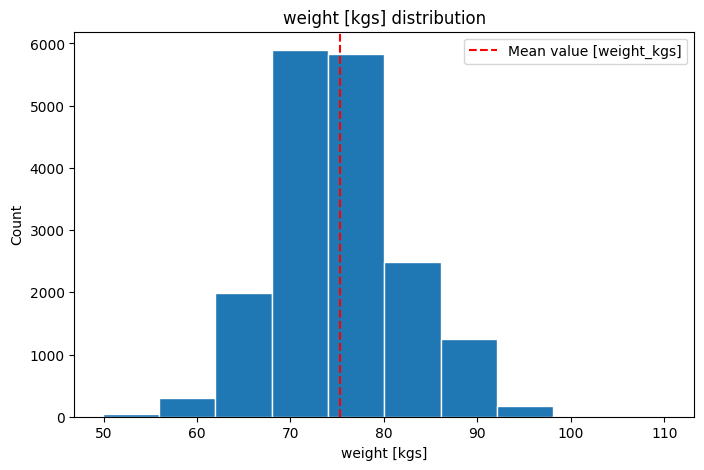

In [932]:
plt.figure(figsize=(8, 5))

# Calculate the mean value of the players weight
mean_height = data['weight_kgs'].mean()

# Plot a histogram showing the distribution of players weight
plt.hist(data['weight_kgs'], bins=10, edgecolor='white')

plt.axvline(
    mean_height,
    color='r',
    linestyle='--',
    label='Mean value [weight_kgs]'
)

plt.xlabel('weight [kgs]')
plt.ylabel('Count')
plt.title('weight [kgs] distribution')
plt.legend()
plt.show()

#### 3. birth_date

In [933]:
# Split the birth_date column into three separate columns: month, day, and year.
# The date is expected to be in the format month/day/year.
data[['month', 'day', 'year']] = data['birth_date'].str.split('/', expand=True)

# Remove the original birth_date column because we already extracted its information.
data = data.drop(columns=['birth_date'])

# Convert the day column from text/object type to integer.
data['day'] = data['day'].astype(int)

# Convert the month column from text/object type to integer.
data['month'] = data['month'].astype(int)

# Convert the year column from text/object type to integer.
data['year'] = data['year'].astype(int)

### Zodiac Signs and Football Player Performance

In this section, we will examine the zodiac signs of the football players in the dataset. The goal is to explore whether there are any visible patterns or relationships between a player's zodiac sign and their performance indicators, as well as possible connections with other features.

There is a lot of popular information online suggesting that people born under the same zodiac sign may share certain personality traits. Although astrology is not considered a scientific method for evaluating athletic ability, this feature can still be explored from a data analysis perspective. The purpose here is not to prove causation, but to check whether any interesting patterns appear in the available data.

In [934]:
def zodiac_sign(day, month):
    """
    Returns the zodiac sign based on day and month.
    :param day: Day of birth.
    :param month: Month of birth.
    :return: Zodiac sign as a string or None.
    """
    if (month == 3 and day >= 21) or (month == 4 and day <= 19):
        return 'Aries'
    elif (month == 4 and day >= 20) or (month == 5 and day <= 20):
        return 'Taurus'
    elif (month == 5 and day >= 21) or (month == 6 and day <= 20):
        return 'Gemini'
    elif (month == 6 and day >= 21) or (month == 7 and day <= 22):
        return 'Cancer'
    elif (month == 7 and day >= 23) or (month == 8 and day <= 22):
        return 'Leo'
    elif (month == 8 and day >= 23) or (month == 9 and day <= 22):
        return 'Virgo'
    elif (month == 9 and day >= 23) or (month == 10 and day <= 22):
        return 'Libra'
    elif (month == 10 and day >= 23) or (month == 11 and day <= 21):
        return 'Scorpio'
    elif (month == 11 and day >= 22) or (month == 12 and day <= 21):
        return 'Sagittarius'
    elif (month == 12 and day >= 22) or (month == 1 and day <= 19):
        return 'Capricorn'
    elif (month == 1 and day >= 20) or (month == 2 and day <= 18):
        return 'Aquarius'
    elif (month == 2 and day >= 19) or (month == 3 and day <= 20):
        return 'Pisces'
    return None

In [935]:
data['zodiac'] = data.apply(
    lambda row: zodiac_sign(row['day'], row['month']),
    axis=1
)

In [936]:
data

,name,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,...,vision,penalties,composure,marking,standing_tackle,sliding_tackle,month,day,year,zodiac
0,L. Messi,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,...,94,75,96,33,28,26,6,24,1987,Cancer
1,C. Eriksen,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,...,91,67,88,59,57,22,2,14,1992,Aquarius
2,P. Pogba,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,...,88,82,87,63,67,67,3,15,1993,Pisces
3,L. Insigne,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,...,87,61,83,51,24,22,6,4,1991,Gemini
4,K. Koulibaly,Kalidou Koulibaly,27,187.96,88.9,CB,Senegal,88,91,60000000.0,...,49,33,80,91,88,87,6,20,1991,Gemini
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,975000.0,...,64,63,56,40,20,18,10,7,1993,Libra
17950,M. Sipľak,Michal Sipľak,23,182.88,79.8,LB,Slovakia,59,67,190000.0,...,39,32,52,53,64,60,2,2,1996,Aquarius
17951,J. Bekkema,Jan Bekkema,22,185.42,89.8,GK,Netherlands,59,67,170000.0,...,25,16,47,9,12,13,4,9,1996,Aries
17952,A. Al Yami,Abdulrahman Al Yami,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,280000.0,...,52,50,53,16,18,17,6,19,1997,Gemini


In [937]:
# Find all unique football positions in the dataset.
# Some players have multiple positions stored in one cell, separated by commas.
unique_positions = (
    data['positions']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
)

unique_positions

array(['CF', 'RW', 'ST', 'CAM', 'RM', 'CM', 'LW', 'CB', 'GK', 'CDM', 'LB',
       'LM', 'RB', 'RWB', 'LWB'], dtype=object)

##### Football Positions

| Position | Full Info                    |
|---|------------------------------|
| GK | Goalkeeper                   |
| CB | Centre Back                  |
| LB | Left Back                    |
| RB | Right Back                   |
| LWB | Left Wing Back               |
| RWB | Right Wing Back              |
| CDM | Central Defensive Midfielder |
| CM | Central Midfielder           |
| CAM | Central Attacking Midfielder |
| LM | Left Midfielder              |
| RM | Right Midfielder             |
| LW | Left Winger                  |
| RW | Right Winger                 |
| CF | Centre Forward               |
| ST | Striker                      |
```


In [938]:
# Create a new DataFrame with only the columns needed for this analysis:
# zodiac signs and player positions.
# dropna() removes rows where either zodiac or positions is missing.
# copy() creates a separate copy, so we avoid modifying the original data accidentally.
zodiac_positions = data[['zodiac', 'positions']].dropna().copy()

# Split the positions column by comma.
# Some players can play in multiple positions, for example: "ST, LW, RW".
# After this step, each cell becomes a list of positions.
zodiac_positions['positions'] = zodiac_positions['positions'].str.split(',')

# Convert each position from the list into a separate row.
# This allows one player with multiple positions to be counted once for each position.
zodiac_positions = zodiac_positions.explode('positions')

# Remove extra spaces around position names.
# For example, " LW" becomes "LW".
zodiac_positions['positions'] = zodiac_positions['positions'].str.strip()

# Create a cross-tabulation table.
# Rows represent zodiac signs.
# Columns represent football positions.
# Each cell shows how many players from a zodiac sign can play in that position.
positions_data = pd.crosstab(
    zodiac_positions['zodiac'],
    zodiac_positions['positions']
)

# Display the final table.
positions_data

positions,CAM,CB,CDM,CF,CM,GK,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
zodiac,,,,,,,,,,,,,,,
Aquarius,232,435,276,30,383,212,232,276,97,29,204,273,109,36,290
Aries,200,340,264,19,329,223,175,226,90,34,190,205,82,31,279
Cancer,175,304,204,29,316,169,193,214,90,27,167,190,91,27,255
Capricorn,199,327,263,31,374,167,184,238,84,27,182,223,90,23,300
Gemini,163,280,230,33,329,167,144,194,80,18,150,209,81,18,244
Leo,142,290,218,32,282,151,151,183,73,25,164,191,68,23,253
Libra,152,266,193,29,267,155,138,169,71,20,178,163,58,28,232
Pisces,305,403,305,58,425,257,220,285,93,25,241,279,102,35,400
Sagittarius,136,194,158,24,225,127,125,170,67,15,108,150,65,14,217


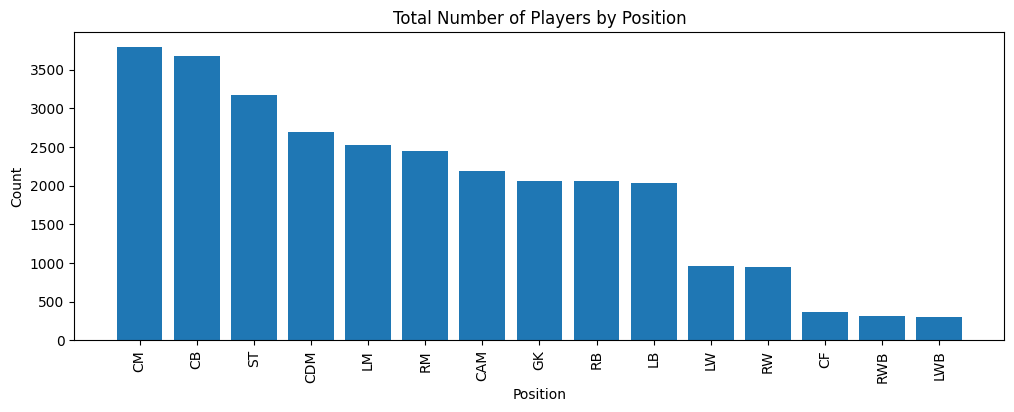

In [939]:
# Split players with multiple positions and count each position separately
position_counts = (
    data['positions']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

plt.figure(figsize=(12, 4))

plt.bar(position_counts.index, position_counts.values)

plt.title('Total Number of Players by Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

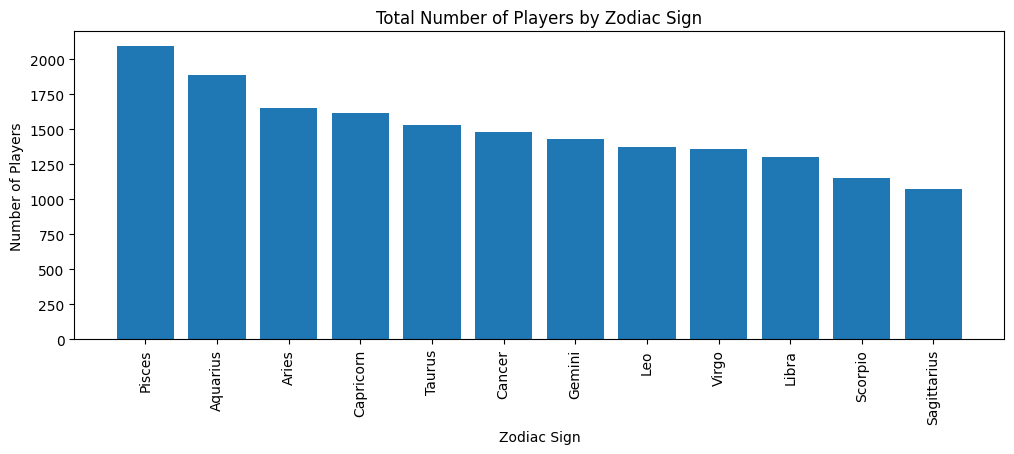

In [940]:
# Count players by zodiac sign
zodiac_counts = data['zodiac'].value_counts()

plt.figure(figsize=(12, 4))

plt.bar(zodiac_counts.index, zodiac_counts.values)

plt.title('Total Number of Players by Zodiac Sign')
plt.xlabel('Zodiac Sign')
plt.ylabel('Number of Players')
plt.xticks(rotation=90)

plt.show()

In [941]:
# Convert the position count table into percentages.
# Each column represents one football position.
# Each value shows what percentage of players in that position belong to each zodiac sign.
positions_percent = (
    positions_data
    .div(positions_data.sum(axis=0), axis=1)
    .mul(100)
    .round(2)
)

positions_percent

positions,CAM,CB,CDM,CF,CM,GK,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
zodiac,,,,,,,,,,,,,,,
Aquarius,10.62,11.84,10.23,8.29,10.09,10.27,11.38,10.95,10.14,9.70,9.92,11.13,11.58,11.46,9.14
Aries,9.15,9.25,9.78,5.25,8.67,10.80,8.58,8.96,9.40,11.37,9.24,8.36,8.71,9.87,8.79
Cancer,8.01,8.27,7.56,8.01,8.33,8.18,9.47,8.49,9.40,9.03,8.12,7.75,9.67,8.60,8.04
Capricorn,9.11,8.90,9.74,8.56,9.86,8.09,9.02,9.44,8.78,9.03,8.85,9.09,9.56,7.32,9.45
Gemini,7.46,7.62,8.52,9.12,8.67,8.09,7.06,7.70,8.36,6.02,7.29,8.52,8.61,5.73,7.69
Leo,6.50,7.89,8.08,8.84,7.43,7.31,7.41,7.26,7.63,8.36,7.97,7.79,7.23,7.32,7.97
Libra,6.96,7.24,7.15,8.01,7.04,7.51,6.77,6.70,7.42,6.69,8.65,6.65,6.16,8.92,7.31
Pisces,13.96,10.97,11.30,16.02,11.20,12.45,10.79,11.31,9.72,8.36,11.72,11.38,10.84,11.15,12.61
Sagittarius,6.22,5.28,5.85,6.63,5.93,6.15,6.13,6.74,7.00,5.02,5.25,6.12,6.91,4.46,6.84


#### 4. nationality analysis

In [942]:
data

,name,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,...,vision,penalties,composure,marking,standing_tackle,sliding_tackle,month,day,year,zodiac
0,L. Messi,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,...,94,75,96,33,28,26,6,24,1987,Cancer
1,C. Eriksen,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,...,91,67,88,59,57,22,2,14,1992,Aquarius
2,P. Pogba,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,...,88,82,87,63,67,67,3,15,1993,Pisces
3,L. Insigne,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,...,87,61,83,51,24,22,6,4,1991,Gemini
4,K. Koulibaly,Kalidou Koulibaly,27,187.96,88.9,CB,Senegal,88,91,60000000.0,...,49,33,80,91,88,87,6,20,1991,Gemini
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,975000.0,...,64,63,56,40,20,18,10,7,1993,Libra
17950,M. Sipľak,Michal Sipľak,23,182.88,79.8,LB,Slovakia,59,67,190000.0,...,39,32,52,53,64,60,2,2,1996,Aquarius
17951,J. Bekkema,Jan Bekkema,22,185.42,89.8,GK,Netherlands,59,67,170000.0,...,25,16,47,9,12,13,4,9,1996,Aries
17952,A. Al Yami,Abdulrahman Al Yami,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,280000.0,...,52,50,53,16,18,17,6,19,1997,Gemini


In [943]:
top_10_football_countries = data['nationality'].value_counts()
top_10_football_countries

nationality
England                 1658
Germany                 1199
Spain                   1070
France                   925
Argentina                904
                        ... 
Kuwait                     1
New Caledonia              1
Oman                       1
São Tomé & Príncipe        1
United Arab Emirates       1
Name: count, Length: 160, dtype: int64

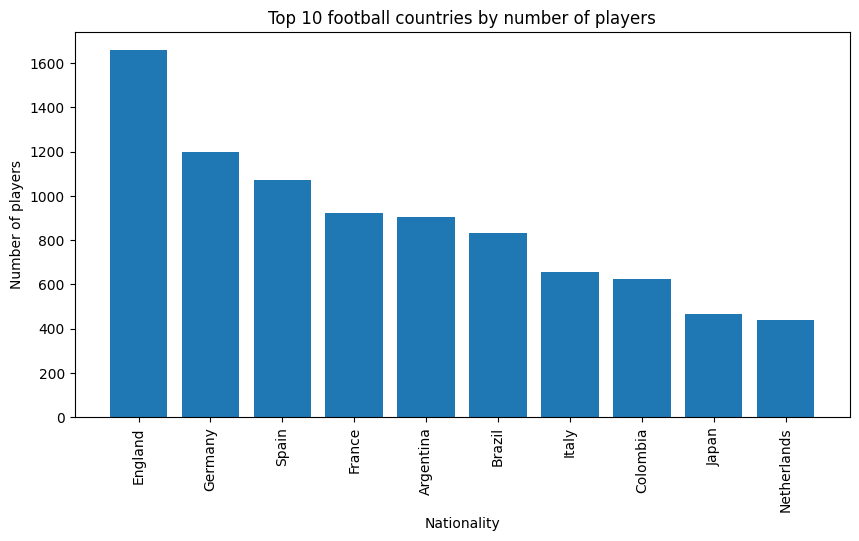

In [944]:
# Get the top 10 nationalities by number of players
top_10_football_countries = data['nationality'].value_counts().head(10)
plt.figure(figsize=(10, 5))

plt.bar(
    top_10_football_countries.index,
    top_10_football_countries.values
)

plt.xlabel('Nationality')
plt.ylabel('Number of players')
plt.title('Top 10 football countries by number of players')
plt.xticks(rotation=90)

plt.show()

### Interesting observation

An interesting observation from the chart is the presence of **Japan** in the top 10 countries by number of football players included in the dataset.

This result shows that the dataset is not dominated only by the traditional European and South American football nations.

#### 5. Performance-Based Wage Prediction and Player Valuation

In [945]:
data

,name,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,...,vision,penalties,composure,marking,standing_tackle,sliding_tackle,month,day,year,zodiac
0,L. Messi,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,...,94,75,96,33,28,26,6,24,1987,Cancer
1,C. Eriksen,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,...,91,67,88,59,57,22,2,14,1992,Aquarius
2,P. Pogba,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,...,88,82,87,63,67,67,3,15,1993,Pisces
3,L. Insigne,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,...,87,61,83,51,24,22,6,4,1991,Gemini
4,K. Koulibaly,Kalidou Koulibaly,27,187.96,88.9,CB,Senegal,88,91,60000000.0,...,49,33,80,91,88,87,6,20,1991,Gemini
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,975000.0,...,64,63,56,40,20,18,10,7,1993,Libra
17950,M. Sipľak,Michal Sipľak,23,182.88,79.8,LB,Slovakia,59,67,190000.0,...,39,32,52,53,64,60,2,2,1996,Aquarius
17951,J. Bekkema,Jan Bekkema,22,185.42,89.8,GK,Netherlands,59,67,170000.0,...,25,16,47,9,12,13,4,9,1996,Aries
17952,A. Al Yami,Abdulrahman Al Yami,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,280000.0,...,52,50,53,16,18,17,6,19,1997,Gemini


In [946]:
data['wage_euro'].isna().sum()

np.int64(246)

In [947]:
performance_data = data.dropna(subset=['wage_euro']).copy()

In [948]:
player_names = performance_data['name']

X = performance_data[
    [
        'crossing',
        'finishing',
        'heading_accuracy',
        'short_passing',
        'volleys',
        'dribbling',
        'curve',
        'freekick_accuracy',
        'long_passing',
        'ball_control',
        'acceleration',
        'sprint_speed',
        'agility',
        'reactions',
        'balance',
        'shot_power',
        'jumping',
        'stamina',
        'strength',
        'long_shots',
        'aggression',
        'interceptions',
        'positioning',
        'vision',
        'penalties',
        'composure',
        'marking',
        'standing_tackle',
        'sliding_tackle'
    ]
]

In [949]:
y = performance_data['wage_euro']
y.isna().sum()

np.int64(0)

In [950]:
y = y.dropna()

In [951]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42
)

In [952]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [953]:
y_pred = model.predict(X_test)

In [954]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 9766.98275817962
R2: 0.270032850266795


## Model Evaluation: Interpretation of Weak Results

The regression model achieved a **Mean Absolute Error (MAE) of approximately 9,767 €** and an **R2 score of approximately 0.27**.

### Mean Absolute Error Interpretation

The MAE value means that, on average, the model's wage predictions differ from the actual player wages by around **9,767 €**.

In the context of football wages, this is a relatively high error. Player salaries can vary significantly between regular players and star players, which makes wage prediction difficult. A small number of highly paid players can strongly affect the model and increase the prediction error.

### R2 Score Interpretation

The **R2 score** shows how much of the variation in the target variable is explained by the model.

In this case:

**R2 = 0.27**

This means that the model explains approximately **27% of the variation in player wages**.

The remaining **73%** of the variation is not explained by the current model.

### Why Are the Results Weak?

The results are relatively weak because the model uses mainly performance-related attributes. However, player wages are influenced by many additional factors that are not fully captured by these features.

For example, wages can depend on:

- player reputation
- age
- club status
- league level
- market value
- contract length
- nationality
- popularity
- previous transfers
- commercial value
- negotiation power

Because these factors are not included in the current feature set, the model cannot fully explain the differences in wages.

### Main Conclusion

The model shows that performance attributes have some relationship with player wages, but they are not enough to make highly accurate salary predictions.

An R2 score of **0.27** suggests that performance explains only a limited part of wage differences. Therefore, football wages are not determined only by on-field abilities, but also by market, club, reputation, and contract-related factors.

## Adding Additional Features

The initial model was based mainly on performance-related attributes. However, the evaluation results showed that these features alone are not sufficient to accurately predict player wages.

To improve the model, we will add several additional features:

- `age`
- `overall_rating`
- `potential`
- `value_euro`

These variables are important because player wages are not determined only by technical and physical performance. They are also strongly influenced by the player's overall quality, future potential, age, and market value.

By including these additional features, the model should be able to capture a broader picture of each player's profile and potentially improve the prediction accuracy.

In [955]:
performance_data

,name,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,...,vision,penalties,composure,marking,standing_tackle,sliding_tackle,month,day,year,zodiac
0,L. Messi,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,...,94,75,96,33,28,26,6,24,1987,Cancer
1,C. Eriksen,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,...,91,67,88,59,57,22,2,14,1992,Aquarius
2,P. Pogba,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,...,88,82,87,63,67,67,3,15,1993,Pisces
3,L. Insigne,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,...,87,61,83,51,24,22,6,4,1991,Gemini
4,K. Koulibaly,Kalidou Koulibaly,27,187.96,88.9,CB,Senegal,88,91,60000000.0,...,49,33,80,91,88,87,6,20,1991,Gemini
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,975000.0,...,64,63,56,40,20,18,10,7,1993,Libra
17950,M. Sipľak,Michal Sipľak,23,182.88,79.8,LB,Slovakia,59,67,190000.0,...,39,32,52,53,64,60,2,2,1996,Aquarius
17951,J. Bekkema,Jan Bekkema,22,185.42,89.8,GK,Netherlands,59,67,170000.0,...,25,16,47,9,12,13,4,9,1996,Aries
17952,A. Al Yami,Abdulrahman Al Yami,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,280000.0,...,52,50,53,16,18,17,6,19,1997,Gemini


In [956]:
performance_data_training_features = [
        'age',
        'overall_rating',
        'potential',
        'value_euro',
        'crossing',
        'finishing',
        'heading_accuracy',
        'short_passing',
        'volleys',
        'dribbling',
        'curve',
        'freekick_accuracy',
        'long_passing',
        'ball_control',
        'acceleration',
        'sprint_speed',
        'agility',
        'reactions',
        'balance',
        'shot_power',
        'jumping',
        'stamina',
        'strength',
        'long_shots',
        'aggression',
        'interceptions',
        'positioning',
        'vision',
        'penalties',
        'composure',
        'marking',
        'standing_tackle',
        'sliding_tackle'
]

In [957]:
performance_data[performance_data_training_features].isna().sum()

age                  0
overall_rating       0
potential            0
value_euro           9
crossing             0
finishing            0
heading_accuracy     0
short_passing        0
volleys              0
dribbling            0
curve                0
freekick_accuracy    0
long_passing         0
ball_control         0
acceleration         0
sprint_speed         0
agility              0
reactions            0
balance              0
shot_power           0
jumping              0
stamina              0
strength             0
long_shots           0
aggression           0
interceptions        0
positioning          0
vision               0
penalties            0
composure            0
marking              0
standing_tackle      0
sliding_tackle       0
dtype: int64

In [958]:
performance_data = performance_data.dropna(subset=['value_euro'])

In [959]:
model_2_data = performance_data[performance_data_training_features]
model_2_data.isna().sum()

age                  0
overall_rating       0
potential            0
value_euro           0
crossing             0
finishing            0
heading_accuracy     0
short_passing        0
volleys              0
dribbling            0
curve                0
freekick_accuracy    0
long_passing         0
ball_control         0
acceleration         0
sprint_speed         0
agility              0
reactions            0
balance              0
shot_power           0
jumping              0
stamina              0
strength             0
long_shots           0
aggression           0
interceptions        0
positioning          0
vision               0
penalties            0
composure            0
marking              0
standing_tackle      0
sliding_tackle       0
dtype: int64

In [960]:
model_2_data

,age,overall_rating,potential,value_euro,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,31,94,94,110500000.0,86,95,70,92,86,97,...,94,48,22,94,94,75,96,33,28,26
1,27,88,89,69500000.0,88,81,52,91,80,84,...,89,46,56,84,91,67,88,59,57,22
2,25,88,91,73000000.0,80,75,75,86,85,87,...,82,78,64,82,88,82,87,63,67,67
3,27,88,88,62000000.0,86,77,56,85,74,90,...,84,34,26,83,87,61,83,51,24,22
4,27,88,91,60000000.0,30,22,83,68,14,69,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,25,67,70,975000.0,57,61,60,66,37,64,...,54,69,41,60,64,63,56,40,20,18
17950,23,59,67,190000.0,50,19,53,55,31,52,...,22,62,55,42,39,32,52,53,64,60
17951,22,59,67,170000.0,11,9,13,26,9,12,...,9,27,10,5,25,16,47,9,12,13
17952,21,59,71,280000.0,42,60,55,49,49,57,...,58,38,15,54,52,50,53,16,18,17


In [961]:
X = model_2_data
y = performance_data['wage_euro']

In [974]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [975]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [976]:
y_pred = model.predict(X_test)

In [977]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 4989.554093744433
R2: 0.7700896725648716


## Model Evaluation After Adding Additional Features

After adding the additional features `age`, `overall_rating`, `potential`, and `value_euro`, the model performance improved significantly.

The new results are:

- **MAE:** 4989.55 €
- **R2:** 0.77

### Result Analysis

The **Mean Absolute Error** decreased from approximately **9,767 €** to **4989.55 €**. This means that the model now makes smaller prediction errors on average when estimating player wages.

The **R2 score** increased from approximately **0.27** to **0.77**. This means that the model now explains around **77% of the variation in player wages**, compared to only 27% in the previous version.

This is a strong improvement and shows that player wages are influenced not only by performance-related attributes, but also by broader player profile factors.

### Conclusion

The improved results indicate that adding `age`, `overall_rating`, `potential`, and especially `value_euro` helped the model capture more important information about each player.

The model now performs much better because it considers both the player's football abilities and his market-related profile. This confirms that wages in football are not determined only by technical and physical skills, but also by overall quality, future potential, age, and market value.

In [978]:
performance_data

,name,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,...,vision,penalties,composure,marking,standing_tackle,sliding_tackle,month,day,year,zodiac
0,L. Messi,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,...,94,75,96,33,28,26,6,24,1987,Cancer
1,C. Eriksen,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,...,91,67,88,59,57,22,2,14,1992,Aquarius
2,P. Pogba,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,...,88,82,87,63,67,67,3,15,1993,Pisces
3,L. Insigne,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,...,87,61,83,51,24,22,6,4,1991,Gemini
4,K. Koulibaly,Kalidou Koulibaly,27,187.96,88.9,CB,Senegal,88,91,60000000.0,...,49,33,80,91,88,87,6,20,1991,Gemini
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,975000.0,...,64,63,56,40,20,18,10,7,1993,Libra
17950,M. Sipľak,Michal Sipľak,23,182.88,79.8,LB,Slovakia,59,67,190000.0,...,39,32,52,53,64,60,2,2,1996,Aquarius
17951,J. Bekkema,Jan Bekkema,22,185.42,89.8,GK,Netherlands,59,67,170000.0,...,25,16,47,9,12,13,4,9,1996,Aries
17952,A. Al Yami,Abdulrahman Al Yami,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,280000.0,...,52,50,53,16,18,17,6,19,1997,Gemini


In [987]:
messi = performance_data[performance_data['name'].str.contains('pogba', case=False)]
messi

,name,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,...,vision,penalties,composure,marking,standing_tackle,sliding_tackle,month,day,year,zodiac
2,P. Pogba,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,...,88,82,87,63,67,67,3,15,1993,Pisces
581,F. Pogba,Florentin Pogba,28,187.96,87.1,"CB,LB",Guinea,74,74,4700000.0,...,42,38,72,73,74,71,8,19,1990,Leo


In [988]:
messi[performance_data_training_features]

,age,overall_rating,potential,value_euro,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
2,25,88,91,73000000.0,80,75,75,86,85,87,...,82,78,64,82,88,82,87,63,67,67
581,28,74,74,4700000.0,64,21,71,64,45,54,...,63,80,73,36,42,38,72,73,74,71


In [989]:
model.predict(messi[performance_data_training_features])

array([234946.78897716,  18157.3158883 ])